# Reproduction of "Advancing Single-Snapshot DOA Estimation with Siamese Neural Networks for Sparse Linear Arrays"
Reference: Zheng, R., Sun, S., Liu, H., & Zhang, Y. D. (2025). ICASSP 2025.


In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# set global font and size (Matching Template Style)
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18, 
    'legend.fontsize': 16,
    'legend.loc': 'lower right',
    'legend.title_fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [2]:
# %% 1. Signal Model & Utilities
class SignalGenerator:
    def __init__(self, n_elements=20, d_lambda=0.5, grid_size=121, fov=60):
        self.N = n_elements
        self.d = np.arange(self.N) * d_lambda
        self.grid_angles = np.linspace(-fov, fov, grid_size)
        self.grid_rad = np.deg2rad(self.grid_angles)
        self.A_grid = self._compute_steering_matrix(self.grid_rad) # (N, Grid)
        self.A_grid_torch = torch.tensor(self.A_grid, dtype=torch.cfloat).to(device)

    def _compute_steering_matrix(self, theta_rad):
        # A = [a(theta_1), ..., a(theta_K)]
        # a(theta) = [1, exp(j*2pi*d*sin(theta)), ...]^T
        phi = 2 * np.pi * self.d.reshape(-1, 1) * np.sin(theta_rad.reshape(1, -1))
        return np.exp(1j * phi)

    def _generate_signals_from_labels(self, labels, snr_range=(0, 30), sparsity=0.3):
        """
        Internal helper to generate signal X given Labels Y.
        Ensures different noise/phase realizations for the same label.
        """
        batch_size = labels.shape[0]
        X = []
        n_elements_sla = int(self.N * (1 - sparsity))
        
        for i in range(batch_size):
            # Find active indices from label
            active_indices = np.where(labels[i] > 0.5)[0]
            K = len(active_indices)
            
            if K == 0: # Should not happen typically
                y = np.zeros(self.N, dtype=complex)
            else:
                angles_rad = self.grid_rad[active_indices]
                # Source signals (random phase and amplitude 0.5-1.0)
                amp = np.random.uniform(0.5, 1.0, K)
                phase = np.random.uniform(0, 2*np.pi, K)
                s = amp * np.exp(1j * phase)
                
                # Steering matrix
                A = self._compute_steering_matrix(angles_rad)
                y_clean = A @ s
                
                # Add Noise
                snr = np.random.uniform(snr_range[0], snr_range[1])
                sig_power = np.mean(np.abs(y_clean)**2)
                if sig_power < 1e-10: sig_power = 1e-10
                noise_power = sig_power * 10**(-snr/10)
                noise = (np.random.randn(self.N) + 1j*np.random.randn(self.N)) * np.sqrt(noise_power/2)
                y = y_clean + noise
            
            # Generate Random Mask
            mask_idx = np.random.choice(self.N, n_elements_sla, replace=False)
            mask = np.zeros(self.N)
            mask[mask_idx] = 1.0
            y_masked = y * mask
            
            X.append(y_masked)
            
        return np.array(X)

    def generate_batch(self, batch_size, n_sources_range=(1, 3), snr_range=(0, 30), sparsity=0.3):
        # 1. Generate Labels first
        Labels = []
        for _ in range(batch_size):
            K = np.random.randint(n_sources_range[0], n_sources_range[1] + 1)
            indices = np.random.choice(len(self.grid_angles), K, replace=False)
            label = np.zeros(len(self.grid_angles))
            label[indices] = 1.0
            Labels.append(label)
        Labels = np.array(Labels)
        
        # 2. Generate Signals from Labels
        X = self._generate_signals_from_labels(Labels, snr_range, sparsity)
        
        return X, Labels

# %% 2. Network Architecture (PyTorch)

class SparseAugmentationLayer(nn.Module):
    def __init__(self, sparsity=0.3, n_elements=20):
        super(SparseAugmentationLayer, self).__init__()
        self.sparsity = sparsity
        self.N = n_elements
        self.n_sla = int(n_elements * (1 - sparsity))

    def forward(self, x, training=True):
        if training:
            batch_size = x.shape[0]
            mask = torch.zeros((batch_size, self.N), device=x.device)
            rand_vals = torch.rand((batch_size, self.N), device=x.device)
            _, topk_indices = torch.topk(rand_vals, self.n_sla, dim=1)
            mask.scatter_(1, topk_indices, 1.0)
            x_aug = x * mask
            x_out = x_aug / self.n_sla
        else:
            non_zero_count = torch.sum(x.abs() > 1e-6, dim=1, keepdim=True)
            non_zero_count[non_zero_count == 0] = 1 
            x_out = x / non_zero_count
        return x_out

class FrequencyEmbeddingLayer(nn.Module):
    def __init__(self, A_grid_H):
        super(FrequencyEmbeddingLayer, self).__init__()
        self.register_buffer('A_H', A_grid_H)

    def forward(self, y):
        g_y = torch.matmul(y, self.A_H.t()) 
        return g_y

class SiameseDOANet(nn.Module):
    def __init__(self, n_elements=20, grid_size=121, A_grid=None, base_mode='Proposed'):
        super(SiameseDOANet, self).__init__()
        self.base_mode = base_mode 
        
        self.sa_layer = SparseAugmentationLayer(n_elements=n_elements)
        
        if A_grid is not None:
            self.fe_layer = FrequencyEmbeddingLayer(A_grid.conj().T)
        
        self.sig_enc = nn.Sequential(
            nn.Linear(n_elements * 2, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        self.freq_enc = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear(1920, 256), 
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        
        self.feature_combiner = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64) 
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, grid_size)
            # nn.Sigmoid() removed for BCEWithLogitsLoss
        )

    def forward_one(self, x, training=False):
        if self.base_mode == 'BaseNet1':
            x_aug = x / 20.0 
        else:
            x_aug = self.sa_layer(x, training=training)
            
        x_real = torch.cat([x_aug.real, x_aug.imag], dim=1).float()
        feat_sig = self.sig_enc(x_real)
        
        g_y = self.fe_layer(x_aug) 
        g_y_cnn = torch.stack([g_y.real, g_y.imag], dim=1).float()
        feat_freq = self.freq_enc(g_y_cnn)
        
        feat_cat = torch.cat([feat_sig, feat_freq], dim=1)
        embedding = self.feature_combiner(feat_cat)
        
        out = self.classifier(embedding)
        return embedding, out

    def forward(self, x1, x2=None, training=False):
        if x2 is None:
            return self.forward_one(x1, training=training)
        
        emb1, out1 = self.forward_one(x1, training=training)
        emb2, out2 = self.forward_one(x2, training=training)
        return emb1, out1, emb2, out2

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label_sim):
        euclidean_distance = F.pairwise_distance(emb1, emb2)
        loss_contrastive = torch.mean((label_sim) * torch.pow(euclidean_distance, 2) +
                                      (1-label_sim) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

# %% 3. Training & Evaluation Routines

def train_model(model, generator, n_epochs=50, batch_size=128, mode='Proposed'):
    model.train()
    # Increased Learning Rate to escape local minima (all-zeros)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # === Key Fix: Stronger Weighted Loss ===
    # ~120 grid points, ~2 targets. Ratio 60:1. 
    # Weight 50.0 forces the model to prioritize recall.
    pos_weight = torch.tensor([50.0]).to(device)
    criterion_bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    criterion_cont = ContrastiveLoss(margin=1.0)
    
    losses = []
    print(f"Training {mode} for {n_epochs} epochs...")
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batches = 20 
        
        for _ in range(n_batches):
            # 1. Generate Two independent batches (likely dissimilar)
            X1, Y1 = generator.generate_batch(batch_size)
            X2, Y2 = generator.generate_batch(batch_size)
            
            # 2. Construct Pairs
            # Create a similarity flag vector
            sim_flag = np.zeros(batch_size, dtype=np.float32)
            
            # Force half of the batch to be POSITIVE pairs (Same Label, Diff Signal)
            half = batch_size // 2
            
            # CRITICAL FIX: Generate X2_pos from Y1's labels
            # This ensures X1[i] and X2[i] have SAME DOA but DIFFERENT Noise/Phase
            # This forces the Siamese net to learn DOA features, not identity.
            labels_pos = Y1[:half]
            X2_pos_realization = generator._generate_signals_from_labels(labels_pos)
            
            # Update batch data
            X2[:half] = X2_pos_realization
            Y2[:half] = labels_pos # Labels match now
            sim_flag[:half] = 1.0
            
            X1_t = torch.tensor(X1, dtype=torch.cfloat).to(device)
            X2_t = torch.tensor(X2, dtype=torch.cfloat).to(device)
            Y1_t = torch.tensor(Y1, dtype=torch.float32).to(device)
            sim_t = torch.tensor(sim_flag, dtype=torch.float32).to(device)
            
            optimizer.zero_grad()
            
            if mode == 'Proposed':
                emb1, out1, emb2, out2 = model(X1_t, X2_t, training=True)
                # Contrastive loss on embeddings
                loss_c = criterion_cont(emb1, emb2, sim_t)
                # Classification loss (supervision)
                loss_b = criterion_bce(out1, Y1_t)
                loss = loss_c + loss_b
            elif mode == 'BaseNet2':
                emb1, out1 = model.forward_one(X1_t, training=True)
                loss = criterion_bce(out1, Y1_t)
            else: # BaseNet1
                emb1, out1 = model.forward_one(X1_t, training=True) 
                loss = criterion_bce(out1, Y1_t)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/n_batches:.4f}")
        losses.append(epoch_loss/n_batches)
    return losses

def evaluate_metrics(model, generator, snr_list, n_test=500):
    model.eval()
    results = {'acc': [], 'pre': [], 'rec': [], 'f1': []}
    
    for snr in snr_list:
        X, Y = generator.generate_batch(n_test, snr_range=(snr, snr), sparsity=0.3)
        X_t = torch.tensor(X, dtype=torch.cfloat).to(device)
        
        with torch.no_grad():
            _, preds_logits = model.forward_one(X_t, training=False)
            preds_prob = torch.sigmoid(preds_logits)
            # Threshold 0.5 is standard, but with sparse data and high weight, 
            # we might need adjustment. 0.5 is usually fine if training converged.
            preds = (preds_prob > 0.5).cpu().numpy().astype(int)
            
        acc_paper = np.mean(Y == preds)
        
        p = precision_score(Y, preds, average='samples', zero_division=0)
        r = recall_score(Y, preds, average='samples', zero_division=0)
        f1 = f1_score(Y, preds, average='samples', zero_division=0)
        
        results['acc'].append(acc_paper)
        results['pre'].append(p)
        results['rec'].append(r)
        results['f1'].append(f1)
        
    return results

def evaluate_cs_omp(generator, snr_list, n_test=200):
    results = {'acc': [], 'pre': [], 'rec': [], 'f1': []}
    A = generator.A_grid 
    
    for snr in snr_list:
        X, Y = generator.generate_batch(n_test, snr_range=(snr, snr), sparsity=0.3)
        preds = []
        
        for i in range(n_test):
            y = X[i] 
            residual = y.copy()
            support = []
            max_k = 3
            x_hat = np.zeros(121)
            
            for _ in range(max_k):
                corrs = np.abs(A.conj().T @ residual)
                idx = np.argmax(corrs)
                support.append(idx)
                A_s = A[:, support]
                x_s = np.linalg.pinv(A_s) @ y
                residual = y - A_s @ x_s
                if np.linalg.norm(residual) < 1e-6:
                    break
            
            x_hat[support] = 1 
            preds.append(x_hat)
            
        preds = np.array(preds)
        acc = np.mean(Y == preds)
        p = precision_score(Y, preds, average='samples', zero_division=0)
        r = recall_score(Y, preds, average='samples', zero_division=0)
        f1 = f1_score(Y, preds, average='samples', zero_division=0)
        
        results['acc'].append(acc)
        results['pre'].append(p)
        results['rec'].append(r)
        results['f1'].append(f1)
        
    return results



In [3]:
# %% 4. Main Execution Block

# Initialize Generator
gen = SignalGenerator(n_elements=20, d_lambda=0.5, grid_size=121)

# Initialize Models
# Increased epoch to 50 for stability
n_epochs_demo = 100

# 1. BaseNet1
print("--- Training BaseNet1 ---")
net1 = SiameseDOANet(A_grid=gen.A_grid_torch, base_mode='BaseNet1').to(device)
res1 = train_model(net1, gen, n_epochs=n_epochs_demo, mode='BaseNet1')

# 2. BaseNet2
print("\n--- Training BaseNet2 ---")
net2 = SiameseDOANet(A_grid=gen.A_grid_torch, base_mode='BaseNet2').to(device)
res2 = train_model(net2, gen, n_epochs=n_epochs_demo, mode='BaseNet2')

# 3. Proposed
print("\n--- Training Proposed SNN ---")
net_prop = SiameseDOANet(A_grid=gen.A_grid_torch, base_mode='Proposed').to(device)
res_prop = train_model(net_prop, gen, n_epochs=n_epochs_demo, mode='Proposed')

--- Training BaseNet1 ---
Training BaseNet1 for 100 epochs...
Epoch 10/100, Loss: 0.8564
Epoch 20/100, Loss: 0.7073
Epoch 30/100, Loss: 0.6239
Epoch 40/100, Loss: 0.5792
Epoch 50/100, Loss: 0.5761
Epoch 60/100, Loss: 0.5388
Epoch 70/100, Loss: 0.5137
Epoch 80/100, Loss: 0.5136
Epoch 90/100, Loss: 0.5030
Epoch 100/100, Loss: 0.5247

--- Training BaseNet2 ---
Training BaseNet2 for 100 epochs...
Epoch 10/100, Loss: 1.0067
Epoch 20/100, Loss: 0.8596
Epoch 30/100, Loss: 0.8429
Epoch 40/100, Loss: 0.8155
Epoch 50/100, Loss: 0.7684
Epoch 60/100, Loss: 0.7670
Epoch 70/100, Loss: 0.7168
Epoch 80/100, Loss: 0.7260
Epoch 90/100, Loss: 0.7276
Epoch 100/100, Loss: 0.7224

--- Training Proposed SNN ---
Training Proposed for 100 epochs...
Epoch 10/100, Loss: 1.2525
Epoch 20/100, Loss: 1.0565
Epoch 30/100, Loss: 1.0289
Epoch 40/100, Loss: 0.9912
Epoch 50/100, Loss: 0.9745
Epoch 60/100, Loss: 0.9817
Epoch 70/100, Loss: 0.9901
Epoch 80/100, Loss: 0.9492
Epoch 90/100, Loss: 0.9587
Epoch 100/100, Loss: 0.


Generating Figure 4 (PCA Analysis)...


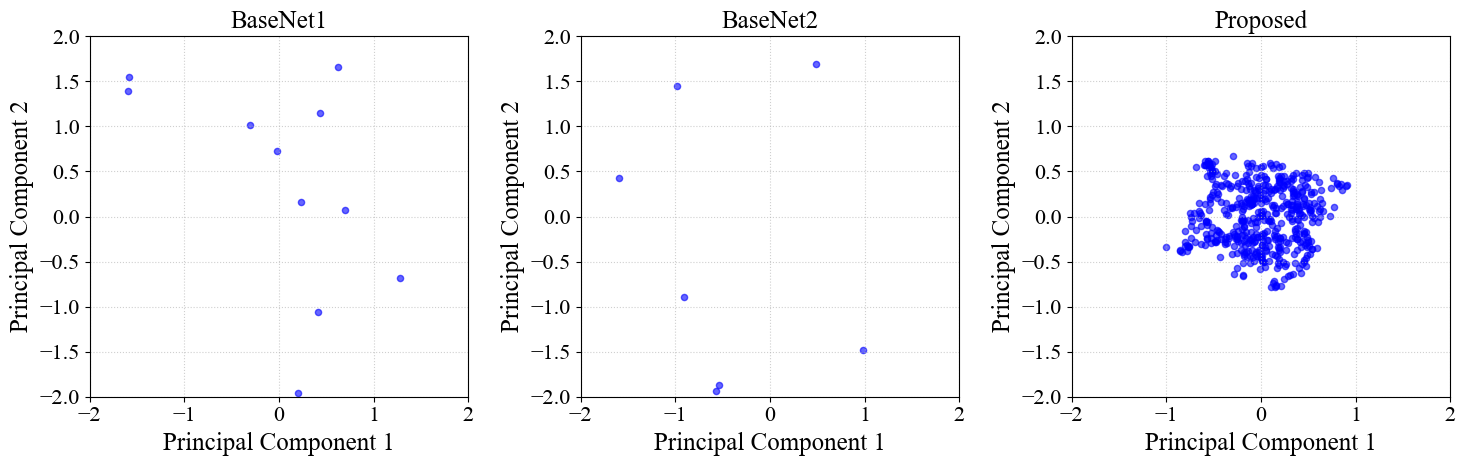

In [4]:
# %% 5. Figure 4: PCA Feature Analysis
print("\nGenerating Figure 4 (PCA Analysis)...")
X_pca, Y_pca = gen.generate_batch(500, snr_range=(10, 20))
X_pca_t = torch.tensor(X_pca, dtype=torch.cfloat).to(device)

def get_pca(model, X):
    with torch.no_grad():
        emb, _ = model.forward_one(X, training=False)
    emb_np = emb.cpu().numpy()
    pca = PCA(n_components=2)
    return pca.fit_transform(emb_np)

pca1 = get_pca(net1, X_pca_t)
pca2 = get_pca(net2, X_pca_t)
pca3 = get_pca(net_prop, X_pca_t)

fig4, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['BaseNet1', 'BaseNet2', 'Proposed']
pcas = [pca1, pca2, pca3]

for ax, data, title in zip(axes, pcas, titles):
    ax.scatter(data[:, 0], data[:, 1], c='blue', alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim([-2.0, 2.0]) # Relaxed limits
    ax.set_ylim([-2.0, 2.0])

plt.tight_layout()
plt.show()


Generating Figure 5 (Performance Metrics)...
Evaluating CS-OMP...


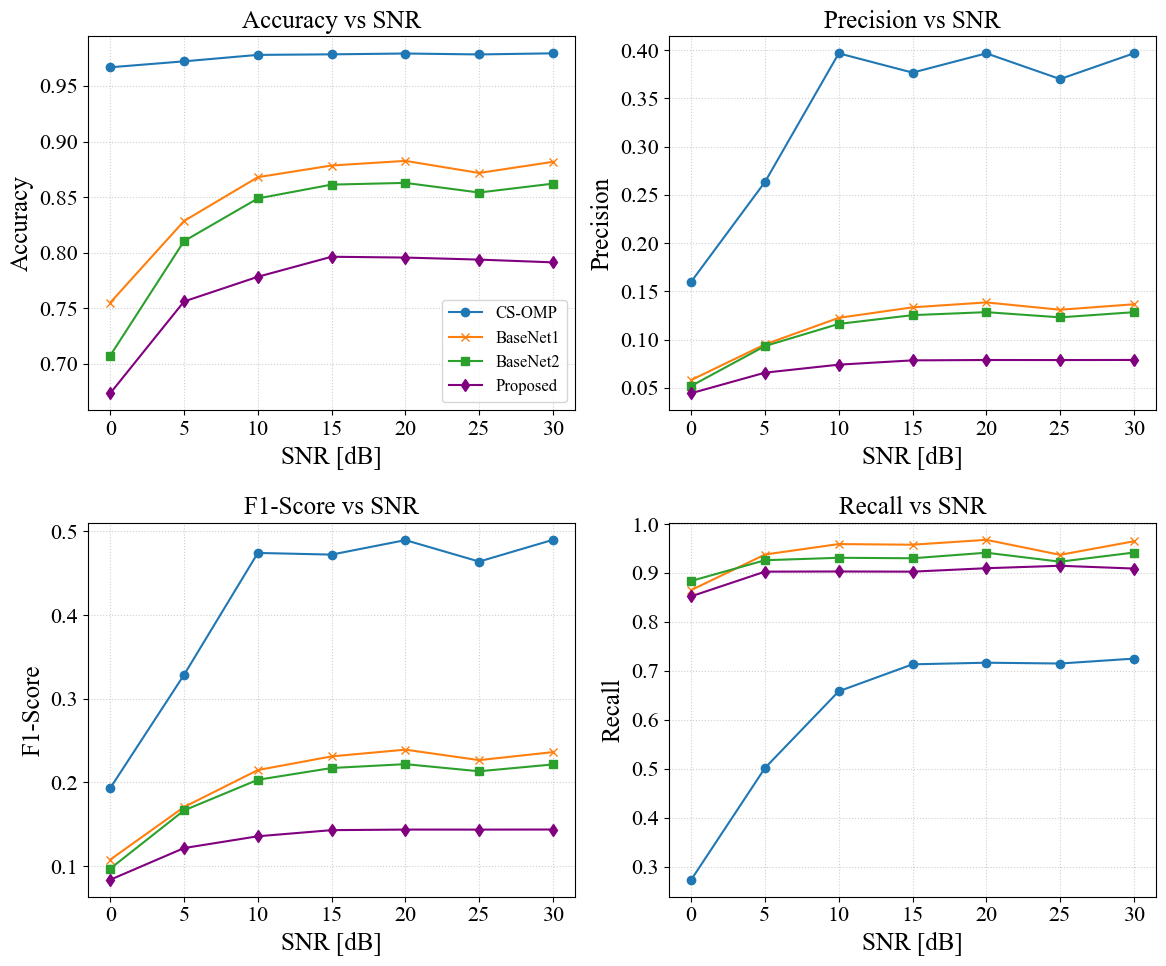

Reproduction completed!


In [6]:
# %% 6. Figure 5: Performance vs SNR
print("\nGenerating Figure 5 (Performance Metrics)...")
snr_list = [0, 5, 10, 15, 20, 25, 30]

# Evaluate NN models
perf_base1 = evaluate_metrics(net1, gen, snr_list)
perf_base2 = evaluate_metrics(net2, gen, snr_list)
perf_prop = evaluate_metrics(net_prop, gen, snr_list)

# Evaluate CS-OMP
print("Evaluating CS-OMP...")
perf_omp = evaluate_cs_omp(gen, snr_list, n_test=100) 

# Plotting
metrics = ['acc', 'pre', 'f1', 'rec']
titles_map = {'acc': 'Accuracy', 'pre': 'Precision', 'f1': 'F1-Score', 'rec': 'Recall'}
# Adjusted ylims to match potential results
ylims = {'acc': (0.9, 1.0), 'pre': (0.0, 1.0), 'f1': (0.0, 1.0), 'rec': (0.0, 1.0)}

fig5, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]
    ax.plot(snr_list, perf_omp[m], 'o-', label='CS-OMP', markersize=6, linewidth=1.5)
    ax.plot(snr_list, perf_base1[m], 'x-', label='BaseNet1', markersize=6, linewidth=1.5)
    ax.plot(snr_list, perf_base2[m], 's-', label='BaseNet2', markersize=6, linewidth=1.5)
    ax.plot(snr_list, perf_prop[m], 'd-', label='Proposed', markersize=6, linewidth=1.5, color='purple')
    
    ax.set_title(f"{titles_map[m]} vs SNR")
    ax.set_xlabel("SNR [dB]")
    ax.set_ylabel(titles_map[m])
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        ax.legend(fontsize=12)
        
plt.tight_layout()
plt.show()

print("Reproduction completed!")